# NMPC benchmark — CSTR–separator

Nonlinear MPC on the **exact** `models.CSTRSeparator` ODE (same plant as the simulator). Same `sim_setup.pkl` as `N4SID.ipynb`: references, input/output bounds, `Qy` / `Qu` / `Qdu`, horizon `N`, and the T10 / xA10 plant upsets.

This is a best-case benchmark:

- Prediction model = plant ODE, discretized with the same multi-step RK4 map as the EKF (matches the plant `RK45` stepper). Feed conditions (`T10`, `xA10`, …) are parameters and are copied onto the NMPC/EKF when a plant disturbance is applied.
- Observer = discrete EKF on the 9 states from `y = [T1, T2, T3, xB3]` (no output-disturbance state).
- Target selector (same job as N4SID `TargetEstimation`): feasible SS `(y_s, u_s)` from `Qy_te` / `Qu_te` and the current `y_sp`, `u_sp`. NMPC tracks `(y_s, u_s)`, so turning on `Qu` cannot demand an unreachable `(y_ref, u_sp)`.
- No reference preview.
- Stage cost uses `Qy`, `Qu`, and `Qdu` from `setup.py` (do not retune them here). To prefer `u_sp` when not all CVs are reachable, turn on **`Qu_te`** (target) and **`Qu`** (NMPC) in `setup.py`.

**Run from `CSTRSeparator/Control`** after `python setup.py`.


In [13]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import joblib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

HERE = Path.cwd().resolve()
REPO_ROOT = HERE.parent.parent
SRC_PATH = REPO_ROOT / "src"
if SRC_PATH.as_posix() not in sys.path:
    sys.path.append(SRC_PATH.as_posix())
if HERE.as_posix() not in sys.path:
    sys.path.append(HERE.as_posix())

import importlib
import plant_inference
import nmpc_cstr

importlib.reload(nmpc_cstr)


<module 'nmpc_cstr' from '/Users/patrik/Documents/Research/2025-2026/offset-free-koopman-mpc/CSTRSeparator/Control/nmpc_cstr.py'>

In [14]:
plant_inference.init()
scaler, scalerU = plant_inference.scaler, plant_inference.scalerU
loaded_setup = joblib.load("sim_setup.pkl")

y_names = list(loaded_setup["y_names"])
u_names = list(loaded_setup["u_names"])
Ts = float(loaded_setup["Ts"])
sim_time = int(loaded_setup["sim_time"])
ny, nu = len(y_names), len(u_names)
nx = nmpc_cstr.NX

print("NMPC exact model  nx=%d  nu=%d  ny=%d  N=%s  Ts=%s" % (nx, nu, ny, loaded_setup["N"], Ts))
print("y:", y_names)
print("u:", u_names)


NMPC exact model  nx=9  nu=6  ny=4  N=60  Ts=1.0
y: ['T1', 'T2', 'T3', 'xB3']
u: ['Q1', 'Q2', 'Q3', 'F10', 'F20', 'Fr']


In [15]:
import importlib
importlib.reload(nmpc_cstr)

feed = nmpc_cstr.FeedParams()
current_ref = nmpc_cstr.CurrentRef()
target = nmpc_cstr.TargetSelector(loaded_setup, scaler, scalerU, feed, Ts=Ts)
model = nmpc_cstr.build_model(Ts=Ts)
mpc = nmpc_cstr.build_mpc(model, loaded_setup, scaler, scalerU, feed, current_ref)

x0 = np.asarray(loaded_setup["x_start"], dtype=float).reshape(-1)
u0 = np.asarray(loaded_setup["u_previous_ns"], dtype=float).reshape(-1)
P0, Q_ekf, R_ekf = nmpc_cstr.default_ekf_covariances(loaded_setup)
ekf = nmpc_cstr.DiscreteEKF(x0, P0, Q_ekf, R_ekf, feed, Ts=Ts)

mpc.x0 = x0
mpc.u0 = u0
mpc.set_initial_guess()
plant_inference.reset(x0, Ts=Ts)
print("EKF Q diag:", np.diag(Q_ekf))
print("EKF R diag:", np.diag(R_ekf))
print("Feed params:", feed.values)


EKF Q diag: [1.e-06 1.e-06 1.e-02 1.e-06 1.e-06 1.e-02 1.e-06 1.e-06 1.e-02]
EKF R diag: [2.5e-03 2.5e-03 2.5e-03 1.0e-12]
Feed params: {'T10': 313.0, 'T20': 313.0, 'xA10': 1.0, 'xB10': 0.0, 'xA20': 1.0, 'xB20': 0.0}


In [16]:
y_sim = np.zeros((ny, sim_time + 1))
y_sim_ns = np.zeros((ny, sim_time + 1))
y_true_ns = np.zeros((ny, sim_time + 1))
u_sim = np.zeros((nu, sim_time))
u_sim_ns = np.zeros((nu, sim_time))
x_sim = np.zeros((nx, sim_time + 1))
x_hat = np.zeros((nx, sim_time + 1))
ys_sim = np.zeros((ny, sim_time))
us_sim = np.zeros((nu, sim_time))
xs_sim = np.zeros((nx, sim_time))

y_true_ns[:, 0] = plant_inference.measure_ns()
y_sim_ns[:, 0] = y_true_ns[:, 0]
y_sim[:, 0] = scaler.transform(y_sim_ns[:, 0].reshape(1, -1))[0]
x_sim[:, 0] = plant_inference.x.copy()
x_hat[:, 0] = ekf.x.copy()

disturbances = list(loaded_setup["disturbances"])
dist_by_k = {int(d["k"]): d for d in disturbances}
noise_sigma = np.asarray(loaded_setup["noise_sigma"], dtype=float)
reference_ns = np.asarray(loaded_setup["reference_ns"], dtype=float)
u_sp_ns = np.asarray(loaded_setup["reference_u_ns"], dtype=float).reshape(-1)
rng = np.random.default_rng(0)
u_prev_ns = u0.copy()

for k in tqdm(range(sim_time), desc="NMPC closed-loop", ncols=80):
    if k in dist_by_k:
        d = dist_by_k[k]
        plant_inference.apply_disturbance(d["attr"], d["value"])
        feed.set(d["attr"], d["value"])
        print(f"k={k}: {d['label']}  (NMPC/EKF {d['attr']}={feed.values[d['attr']]})")

    xs_sim[:, k], ys_sim[:, k], us_sim[:, k] = target.get_target(
        reference_ns[:, k], u_sp_ns, x_guess=ekf.x, u_guess=u_prev_ns
    )
    current_ref.set(ys_sim[:, k], us_sim[:, k])
    u_opt = np.asarray(mpc.make_step(ekf.x), dtype=float).reshape(-1)
    u_sim_ns[:, k] = u_opt
    u_sim[:, k] = scalerU.transform(u_opt.reshape(1, -1))[0]

    y_scaled = plant_inference.y_plus(u_sim[:, k])
    y_true_ns[:, k + 1] = plant_inference.measure_ns()
    x_sim[:, k + 1] = plant_inference.x.copy()
    noise = rng.normal(0.0, noise_sigma)
    y_meas_ns = y_true_ns[:, k + 1] + noise
    y_sim_ns[:, k + 1] = y_meas_ns
    y_sim[:, k + 1] = scaler.transform(y_meas_ns.reshape(1, -1))[0]

    x_hat[:, k + 1] = ekf.step(u_opt, y_meas_ns)
    u_prev_ns = u_opt


NMPC closed-loop:  40%|████████▊             | 601/1500 [02:36<04:21,  3.44it/s]

k=600: cold feed T10: 313 -> 310 K  (NMPC/EKF T10=310.0)


NMPC closed-loop:  57%|████████████▍         | 851/1500 [03:43<03:16,  3.30it/s]

k=850: lean feed xA10: 1.00 -> 0.97  (NMPC/EKF xA10=0.97)


NMPC closed-loop: 100%|█████████████████████| 1500/1500 [07:29<00:00,  3.33it/s]


In [31]:
Qy, Qu, Qdu = loaded_setup["Qy"], loaded_setup["Qu"], loaded_setup["Qdu"]
reference = loaded_setup["reference"]
u_sp = np.asarray(loaded_setup["reference_u"]).reshape(-1)
u_sp_scaled = scalerU.transform(us_sim[:, k].reshape(1, -1))[0]

objective_value = state_error_cost = control_increment_cost = control_setpoint_cost = 0.0
for k in range(sim_time):
    y_diff = y_sim[:, k] - reference[:, k]
    prev_u = u_sim[:, k - 1] if k > 0 else u_sim[:, k]
    u_diff = u_sim[:, k] - prev_u
    u_sp_scaled = scalerU.transform(us_sim[:, k].reshape(1, -1))[0]
    u_error = u_sp_scaled - u_sim[:, k]
    y_term = float(y_diff.T @ Qy @ y_diff)
    u_term = float(u_diff.T @ Qdu @ u_diff)
    u_sp_term = float(u_error.T @ Qu @ u_error)
    state_error_cost += y_term
    control_increment_cost += u_term
    control_setpoint_cost += u_sp_term
    objective_value += y_term + u_term + u_sp_term

print(f"Closed-loop objective function value: {objective_value}")
print(f"  - State tracking term: {state_error_cost}")
print(f"  - Input increment term: {control_increment_cost}")
print(f"  - Input setpoint term: {control_setpoint_cost}")


Closed-loop objective function value: 145.62960989639097
  - State tracking term: 123.82581296416016
  - Input increment term: 11.304942456685502
  - Input setpoint term: 10.498854475545482


In [ ]:
us_sim[:, k] - u_sim_ns[:, k]


array([16.48835856, 18.53280631, 10.90255671,  8.00536643,  1.34171908,
        4.60818612])

In [23]:
u_sim_ns[:, k]

array([16.48835761, 18.53280524, 10.90255591,  8.00536575,  1.34171907,
        4.60818569])

Saved NMPC_results.pkl


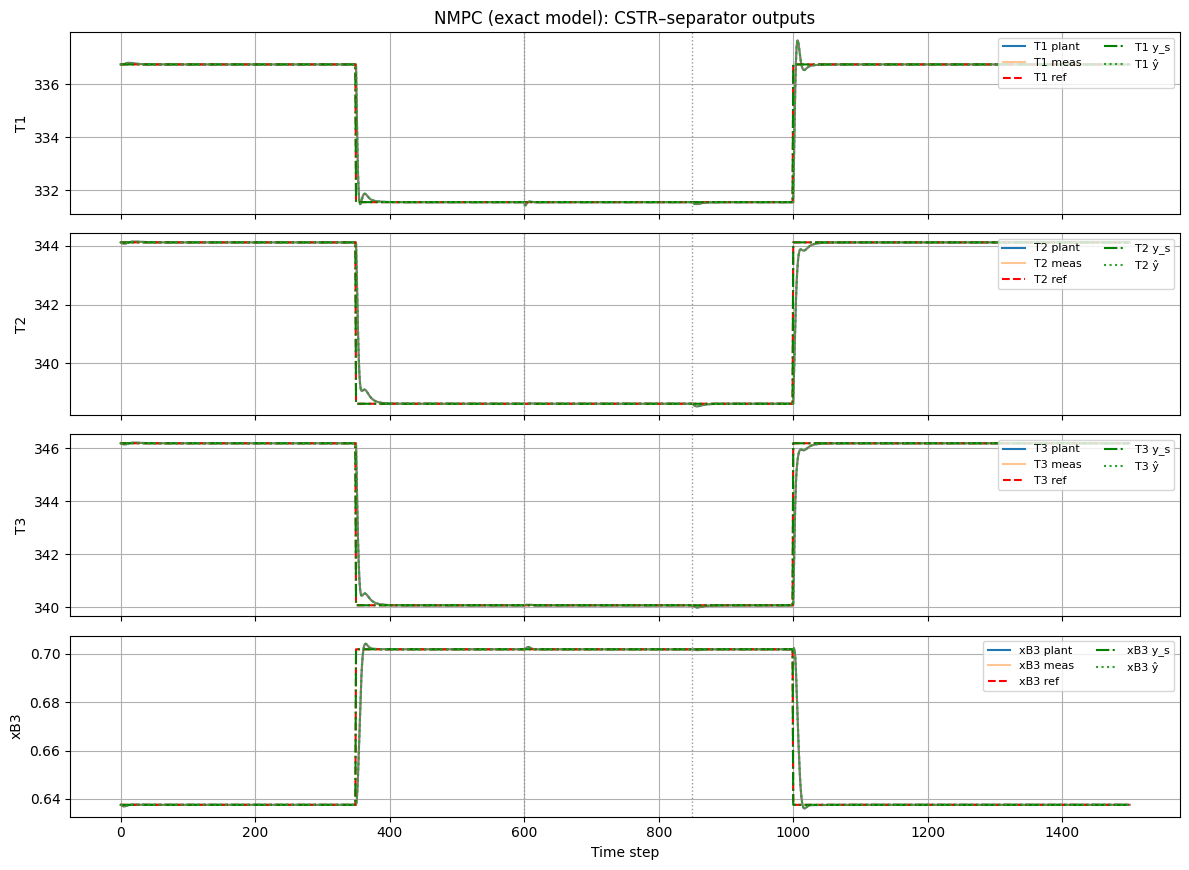

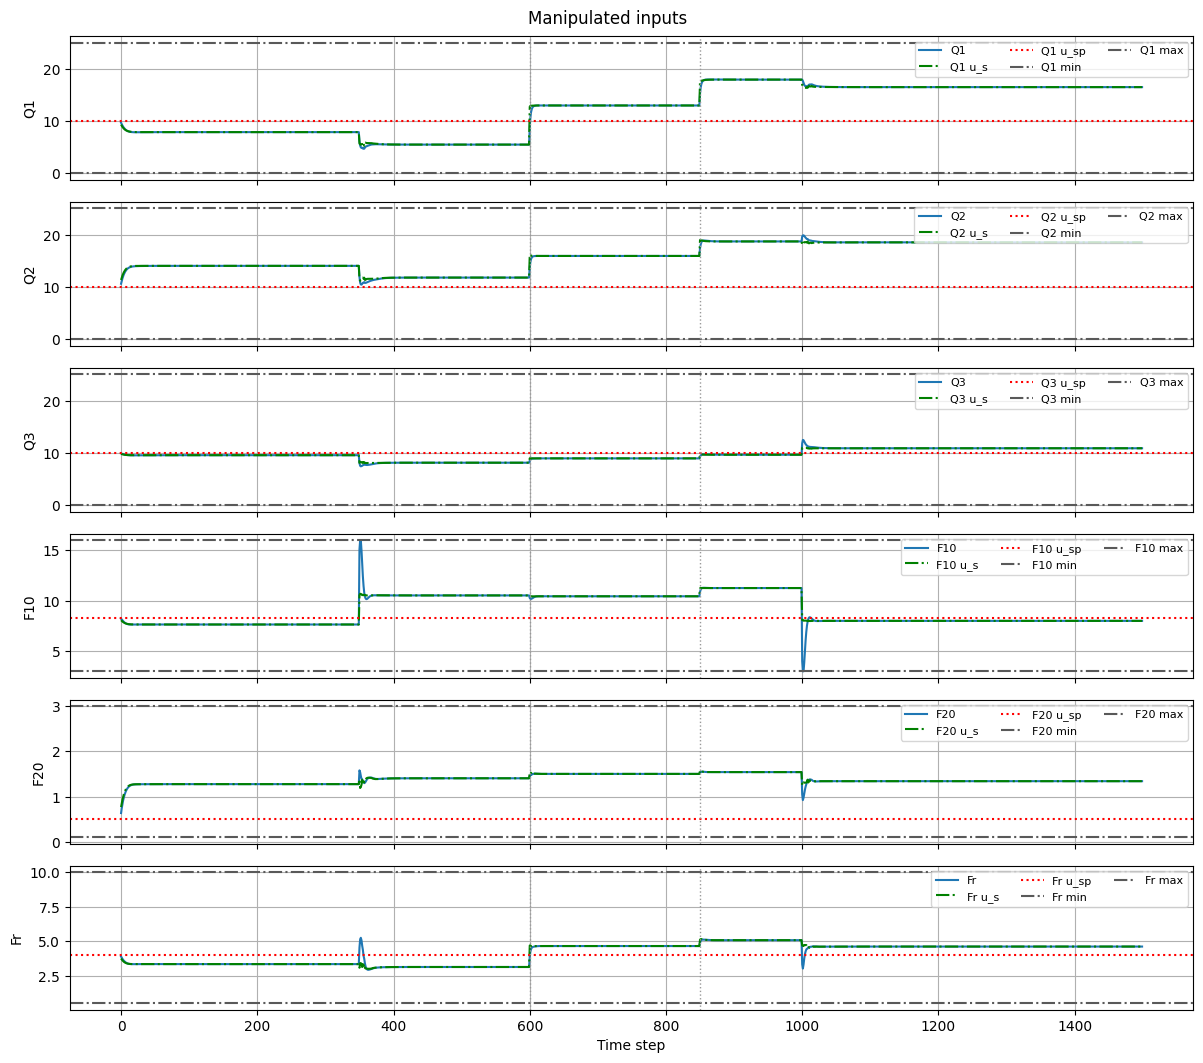

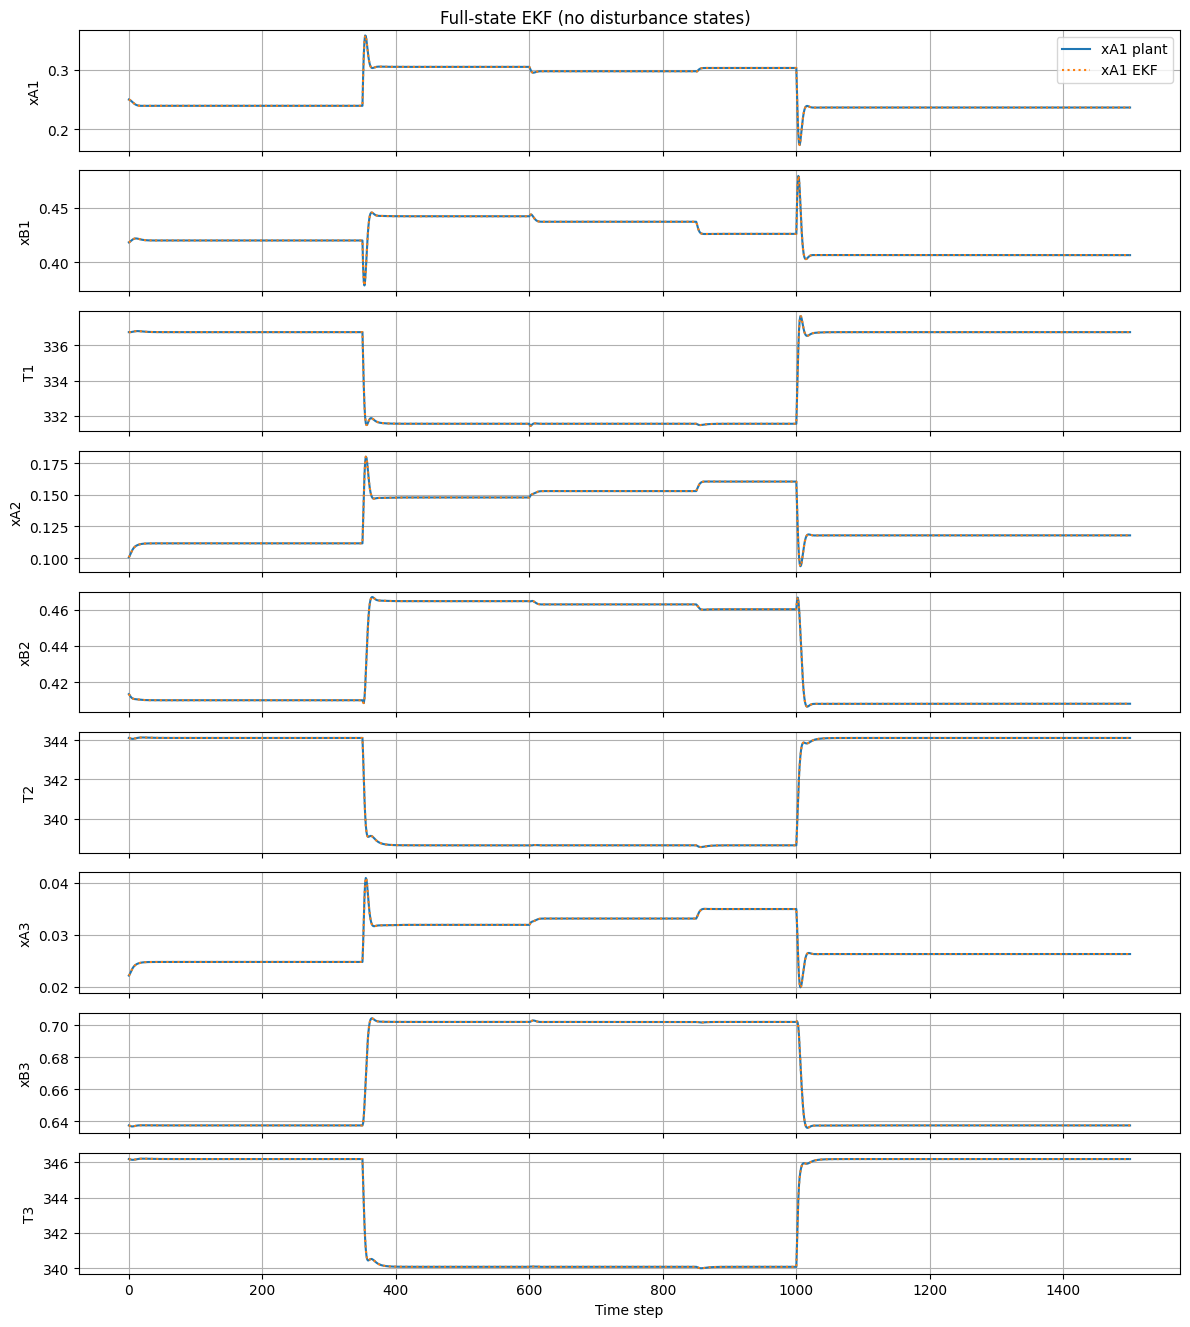

In [18]:
reference_ns = loaded_setup["reference_ns"]
u_sp_ns = np.asarray(loaded_setup["reference_u_ns"]).reshape(-1)
y_hat_ns = x_hat[[2, 5, 8, 7], :]

fig, axs = plt.subplots(ny, 1, figsize=(12, 2.2 * ny), sharex=True)
for i, name in enumerate(y_names):
    axs[i].plot(y_true_ns[i, :], label=f"{name} plant")
    axs[i].plot(y_sim_ns[i, :], alpha=0.45, label=f"{name} meas")
    axs[i].plot(reference_ns[i, :sim_time], "r--", label=f"{name} ref")
    axs[i].plot(ys_sim[i, :], "g-.", label=f"{name} y_s")
    axs[i].plot(y_hat_ns[i, :], ":", label=f"{name} ŷ")
    for d in disturbances:
        axs[i].axvline(int(d["k"]), color="0.6", linestyle=":", linewidth=1)
    axs[i].set_ylabel(name)
    axs[i].grid(True)
    axs[i].legend(loc="upper right", ncol=2, fontsize=8)
axs[-1].set_xlabel("Time step")
axs[0].set_title("NMPC (exact model): CSTR–separator outputs")
fig.tight_layout()

fig_u, axs_u = plt.subplots(nu, 1, figsize=(12, 1.8 * nu), sharex=True)
u_min_ns = np.asarray(loaded_setup["u_min_ns"], dtype=float).reshape(-1)
u_max_ns = np.asarray(loaded_setup["u_max_ns"], dtype=float).reshape(-1)
for i, name in enumerate(u_names):
    axs_u[i].plot(u_sim_ns[i, :], label=name)
    axs_u[i].plot(us_sim[i, :], "g-.", label=f"{name} u_s")
    axs_u[i].axhline(u_sp_ns[i], color="r", linestyle=":", label=f"{name} u_sp")
    axs_u[i].axhline(u_min_ns[i], color="0.35", linestyle="-.", label=f"{name} min")
    axs_u[i].axhline(u_max_ns[i], color="0.35", linestyle="-.", label=f"{name} max")
    for d in disturbances:
        axs_u[i].axvline(int(d["k"]), color="0.6", linestyle=":", linewidth=1)
    axs_u[i].set_ylabel(name)
    axs_u[i].grid(True)
    axs_u[i].legend(loc="upper right", ncol=3, fontsize=8)
axs_u[-1].set_xlabel("Time step")
fig_u.suptitle("Manipulated inputs")
fig_u.tight_layout()

x_names = nmpc_cstr.X_NAMES
fig_x, axs_x = plt.subplots(nx, 1, figsize=(12, 1.5 * nx), sharex=True)
for i, name in enumerate(x_names):
    axs_x[i].plot(x_sim[i, :], label=f"{name} plant")
    axs_x[i].plot(x_hat[i, :], ":", label=f"{name} EKF")
    axs_x[i].set_ylabel(name)
    axs_x[i].grid(True)
    if i == 0:
        axs_x[i].legend(loc="upper right")
axs_x[-1].set_xlabel("Time step")
fig_x.suptitle("Full-state EKF (no disturbance states)")
fig_x.tight_layout()

joblib.dump(
    {
        "y_true_ns": y_true_ns,
        "y_sim_ns": y_sim_ns,
        "u_sim_ns": u_sim_ns,
        "us_sim": us_sim,
        "ys_sim": ys_sim,
        "xs_sim": xs_sim,
        "x_sim": x_sim,
        "x_hat": x_hat,
        "objective": objective_value,
        "state_term": state_error_cost,
        "input_term": control_increment_cost,
        "u_sp_term": control_setpoint_cost,
        "reference_ns": reference_ns,
    },
    "NMPC_results.pkl",
)
print("Saved NMPC_results.pkl")
